In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# Sample data
data = {
    'date': ['2024-09-24', '2024-09-25', '2024-09-26', '2024-09-27', '2024-09-28', '2024-09-29', 
             '2024-09-30', '2024-10-01', '2024-10-02', '2024-10-03', '2024-10-04', '2024-10-05',
             '2024-10-06', '2024-10-07', '2024-10-08', '2024-10-09', '2024-10-10', '2024-10-11',
             '2024-10-12', '2024-10-13'],
    'balance': [138706, 138214, 137241, 134192, 118229, 116883, 113839, 112638, 111951, 110807,
                105434, 103655, 100337, 96591, 86970, 162602, 155813, 155048, 154230, 154108]
}

df = pd.DataFrame(data)


In [3]:
df['date'] = pd.to_datetime(df['date']).map(pd.Timestamp.toordinal)

# Split the data into X (features) and y (target)
X = df[['date']]
y = df['balance']


In [4]:
# Split the data into 70% training and 30% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [5]:
# Create polynomial features (degree 2 in this case)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Fit the model using linear regression
model = LinearRegression()
model.fit(X_train_poly, y_train)


LinearRegression()

In [6]:
# Make predictions
y_train_pred = model.predict(X_train_poly)
y_test_pred = model.predict(X_test_poly)

# Calculate Mean Squared Error for both training and test sets
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print(f'Train MSE: {train_mse}')
print(f'Test MSE: {test_mse}')


Train MSE: 137539098.63030133
Test MSE: 510935740.1842448


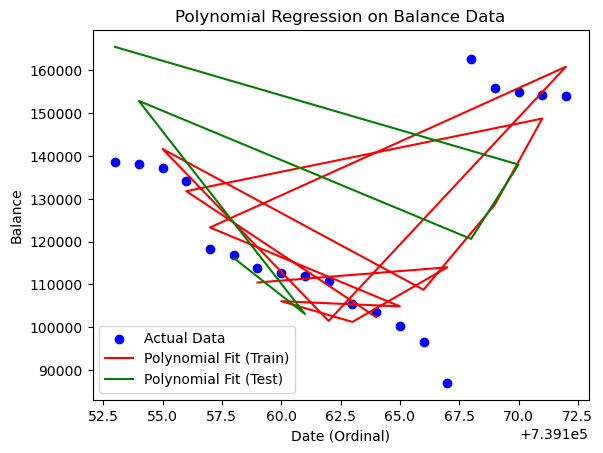

In [7]:
import matplotlib.pyplot as plt

# Plotting the results
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X_train, model.predict(poly.transform(X_train)), color='red', label='Polynomial Fit (Train)')
plt.plot(X_test, model.predict(poly.transform(X_test)), color='green', label='Polynomial Fit (Test)')
plt.xlabel('Date (Ordinal)')
plt.ylabel('Balance')
plt.title('Polynomial Regression on Balance Data')
plt.legend()
plt.show()
